In [17]:
!pip install nltk


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
!pip install emoji


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import emoji

In [21]:
nltk.download('punkit')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Error loading punkit: Package 'punkit' not found in index
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vav\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\vav\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [22]:
df = pd.read_csv("E:\DS\PROJECTS\AI Echo Your Smartest Conversational Partner\AI_Echo_Project\data.csv")
df

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\vav\AppData\Local\Temp\ipykernel_11984\80142580.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("E:\DS\PROJECTS\AI Echo Your Smartest Conversational Partner\AI_Echo_Project\data.csv")


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No
...,...,...,...,...,...,...,...,...,...,...,...,...
495,7/5/2024,Review title 496,"Waste of time, does not meet expectations.",2,user496,81,7,Flipkart,ja,Qatar,1.2.3,No
496,########,Review title 497,"Great experience, smooth performance and usefu...",5,user497,48,7,Google Play,fr,Nepal,2.1.4,No
497,########,Review title 498,"Terrible experience, needs major improvements.",2,user498,16,5,Google Play,de,Poland,2.1.4,Yes
498,########,Review title 499,"Highly satisfied, the app works exactly as exp...",4,user499,68,8,Google Play,zh,Nepal,1.2.3,Yes


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   date               500 non-null    str  
 1   title              500 non-null    str  
 2   review             500 non-null    str  
 3   rating             500 non-null    int64
 4   username           500 non-null    str  
 5   helpful_votes      500 non-null    int64
 6   review_length      500 non-null    int64
 7   platform           500 non-null    str  
 8   language           500 non-null    str  
 9   location           500 non-null    str  
 10  version            500 non-null    str  
 11  verified_purchase  500 non-null    str  
dtypes: int64(3), str(9)
memory usage: 47.0 KB


In [24]:
df.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.describe()

,rating,helpful_votes,review_length
count,500.000000,500.000000,500.000000
mean,3.012000,103.090000,6.934000
std,1.366598,57.747896,1.453916
min,1.000000,0.000000,5.000000
25%,2.000000,55.750000,6.000000
50%,3.000000,104.500000,7.000000
75%,4.000000,152.000000,8.000000
max,5.000000,200.000000,10.000000


In [27]:
df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase'],
      dtype='str')

In [28]:
#Data handling

df=df[['date','review', 'rating','helpful_votes','review_length', 'platform', 'language', 'location', 'version','verified_purchase']]

#Username is a unique identifier and does not contribute to sentiment prediction. 
#Title contains limited text compared to the full review, so the main review text is used for NLP processing.

In [29]:
df['date'].value_counts()

date
########    358
3/2/2024      4
3/7/2024      4
2/1/2025      4
1/6/2024      4
           ... 
7/7/2024      1
3/3/2024      1
3/6/2025      1
4/4/2024      1
7/5/2024      1
Name: count, Length: 88, dtype: int64

In [30]:
df['date']=pd.to_datetime(df['date'],errors='coerce')

#The date column was converted to datetime format to enable time-based analysis such as tracking sentiment trends over time.
#Invalid date values were handled using errors='coerce', which converts them into missing values.

C:\Users\vav\AppData\Local\Temp\ipykernel_11984\540272744.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date']=pd.to_datetime(df['date'],errors='coerce')


In [31]:
df['date'].value_counts()

date
2024-03-02    4
2024-03-07    4
2025-02-01    4
2024-01-06    4
2024-02-03    4
             ..
2024-07-07    1
2024-03-03    1
2025-03-06    1
2024-04-04    1
2024-07-05    1
Name: count, Length: 87, dtype: int64

In [32]:
df['date'].isnull().sum()

np.int64(358)

In [33]:
df=df.dropna(subset=['date'])

In [34]:
df['date'].isnull().sum()

np.int64(0)

In [35]:
def get_sentiment(rating):
    if rating>=4:
        return 'Positive' 
    elif rating==3:
        return 'Neutral'
    else:
        return 'Negative'
    
df['sentiment']=df['rating'].apply(get_sentiment)

In [36]:
sentiment_counts=df['sentiment'].value_counts()
sentiment_counts

sentiment
Negative    58
Positive    54
Neutral     30
Name: count, dtype: int64

In [37]:
df

,date,review,rating,helpful_votes,review_length,platform,language,location,version,verified_purchase,sentiment
5,2024-05-05,"Waste of time, does not meet expectations.",2,156,7,App Store,en,Nepal,3.5.6,No,Negative
6,2024-03-09,"Highly satisfied, the app works exactly as exp...",4,186,8,Google Play,fr,Qatar,2.1.4,No,Positive
7,2024-03-08,"Highly satisfied, the app works exactly as exp...",4,152,8,Amazon,ja,Italy,5.0.3,No,Positive
14,2024-06-02,Works fine but there is room for improvement.,3,78,8,Flipkart,hi,USA,3.5.6,Yes,Neutral
18,2024-06-05,"Excellent app, very easy to use and extremely ...",5,33,9,Website,pt,USA,5.0.3,No,Positive
...,...,...,...,...,...,...,...,...,...,...,...
481,2025-03-06,"Waste of time, does not meet expectations.",1,144,7,Flipkart,en,Germany,4.2.1,Yes,Negative
488,2024-01-04,"Highly satisfied, the app works exactly as exp...",4,123,8,Website,zh,Italy,4.2.1,No,Positive
490,2024-04-04,"Terrible experience, needs major improvements.",1,12,5,Flipkart,en,Qatar,4.2.1,Yes,Negative
495,2024-07-05,"Waste of time, does not meet expectations.",2,81,7,Flipkart,ja,Qatar,1.2.3,No,Negative


#### EDA

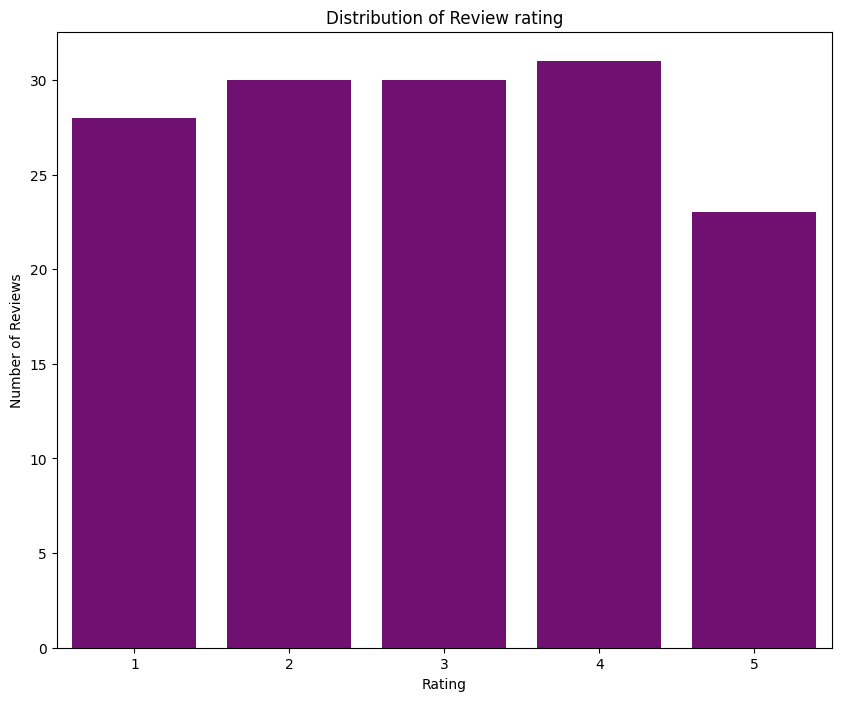

In [38]:
#Rating Distribution

plt.figure(figsize=(10,8))
sns.countplot(x='rating',data=df,color='purple')
plt.title('Distribution of Review rating')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

#Bar chart is used to visualize the distribution of ratings in order to understand overall user satisfaction

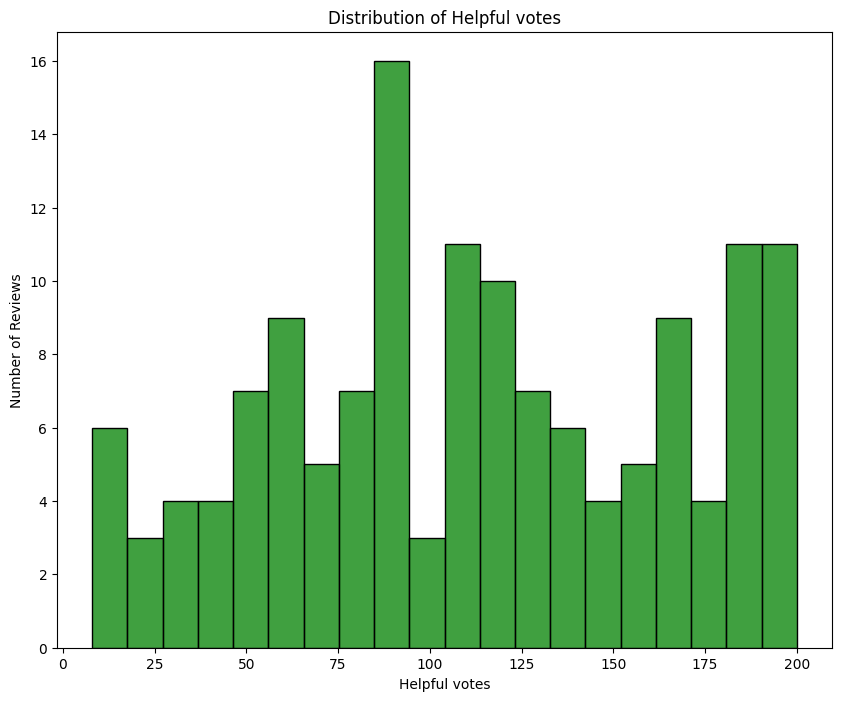

In [39]:
#Helpful vote analysis

plt.figure(figsize=(10,8))
sns.histplot(df['helpful_votes'],bins=20,color='green')
plt.title('Distribution of Helpful votes')
plt.xlabel('Helpful votes')
plt.ylabel('Number of Reviews')
plt.show()

#Helpful votes represent how useful other users find a review. Analyzing this helps identify influential feedback.

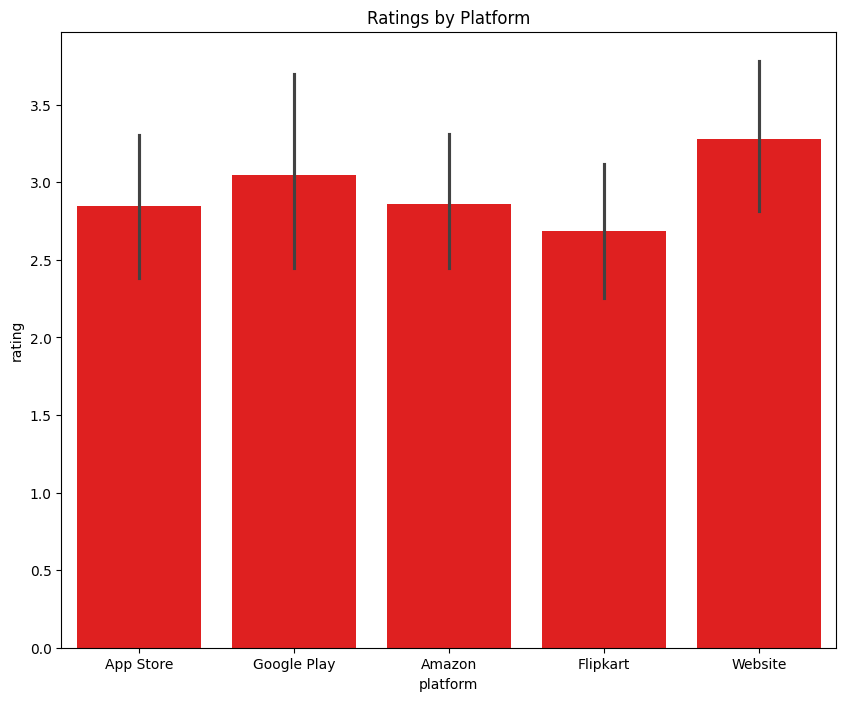

In [40]:
#Platform comparison

plt.figure(figsize=(10,8))
sns.barplot(x="platform", y="rating", data=df,color='red')
plt.title("Ratings by Platform")
plt.show()

#Compares user experience across platforms.

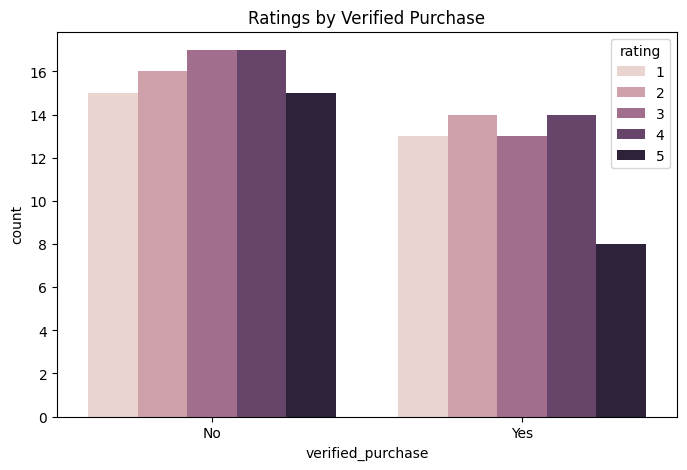

In [41]:
#Verified vs Non-verified

plt.figure(figsize=(8,5))
sns.countplot(x="verified_purchase", hue="rating", data=df)
plt.title("Ratings by Verified Purchase")
plt.show()

#Checks whether paying/verified users give better ratings.

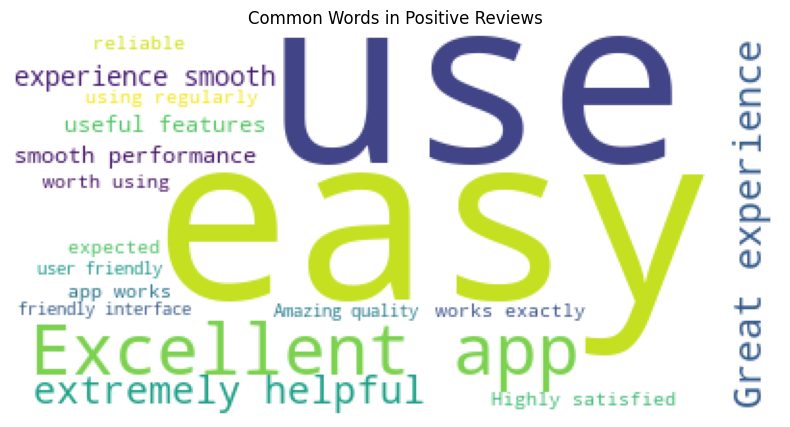

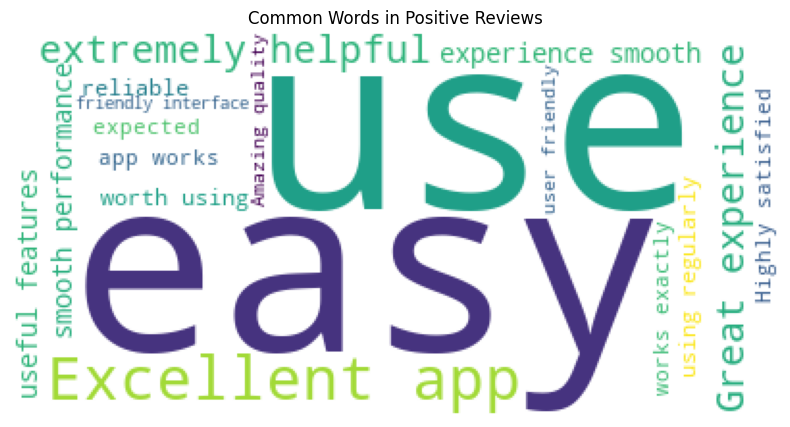

In [42]:
#Most Common Keywords in Positive vs Negative Review

positive_reviews=" ".join(df[df['rating']>=4]['review'])
negative_reviews=" ".join(df[df['rating']<=2]['review'])

#Positive word cloud
plt.figure(figsize=(10,5))
wc_pos = WordCloud(background_color="white").generate(positive_reviews)
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Common Words in Positive Reviews")
plt.show()

plt.figure(figsize=(10,5))
wc_pos = WordCloud(background_color="white").generate(positive_reviews)
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Common Words in Positive Reviews")
plt.show()

#Shows which words appear most frequently in high-rated vs low-rated reviews.

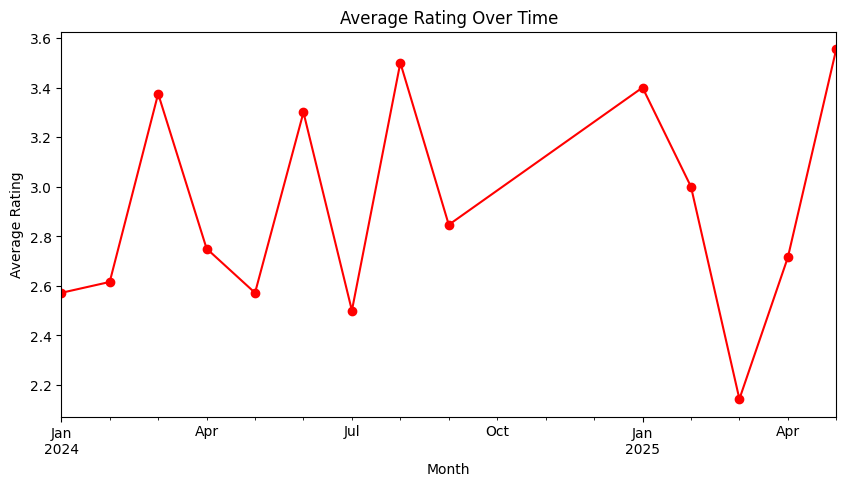

In [43]:
#Average Rating Over Time

rating_trend = df.groupby(df["date"].dt.to_period("M"))["rating"].mean()

rating_trend.plot(kind="line", figsize=(10,5), marker="o",color='red')

plt.title("Average Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.show()

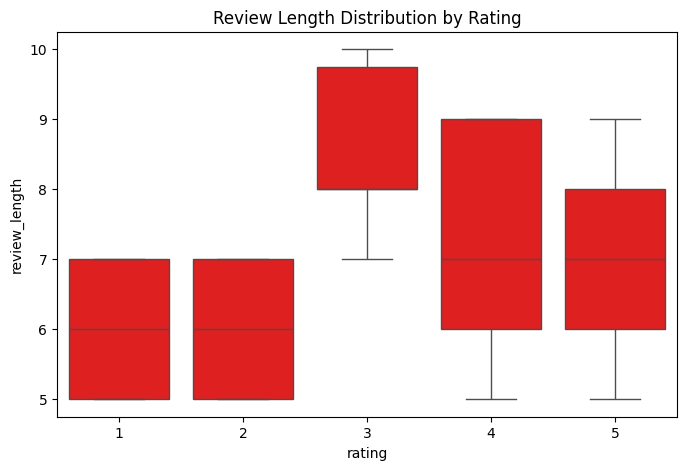

In [44]:
#Review Length vs Rating

plt.figure(figsize=(8,5))
sns.boxplot(x="rating", y="review_length", data=df,color='red')
plt.title("Review Length Distribution by Rating")
plt.show()

#Shows whether unhappy users write longer complaints.

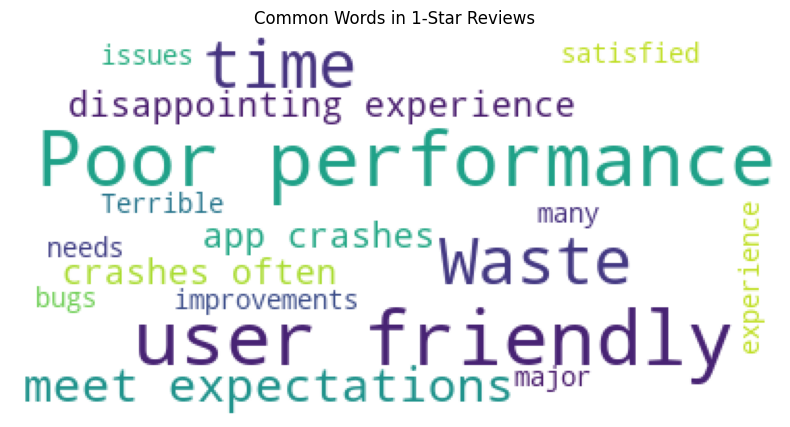

In [45]:
#Most Mentioned Words in 1-Star Reviews

one_star_reviews = " ".join(df[df["rating"] == 1]["review"])
wc_1star = WordCloud(background_color="white").generate(one_star_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wc_1star)
plt.axis("off")
plt.title("Common Words in 1-Star Reviews")
plt.show()

#Highlights frequent complaints in worst reviews.

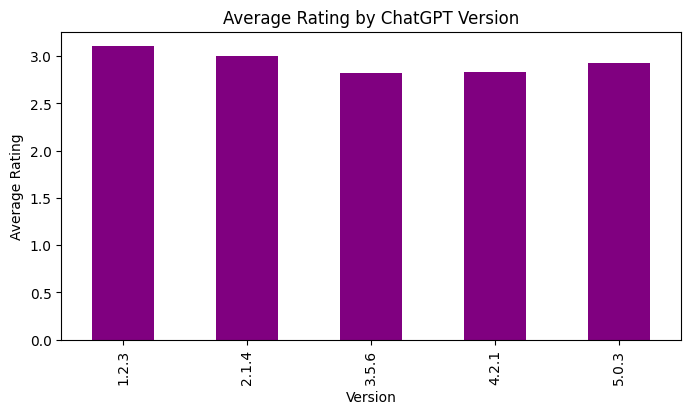

In [46]:
#ChatGPT Version vs Average Rating

version_rating = df.groupby("version")["rating"].mean()
version_rating.plot(kind="bar", figsize=(8,4), color="purple")

plt.title("Average Rating by ChatGPT Version")
plt.xlabel("Version")
plt.ylabel("Average Rating")
plt.show()

#Shows which software version performs best.

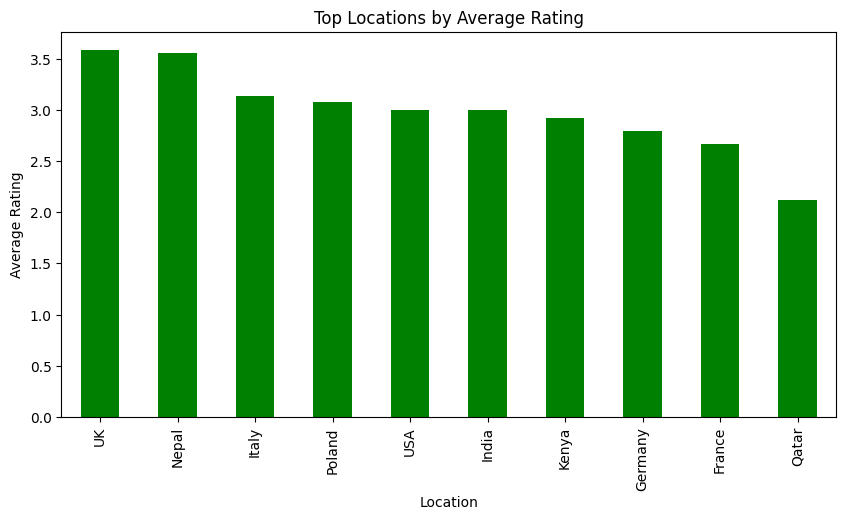

In [47]:
#7.Ratings by User Location
location_rating = df.groupby("location")["rating"].mean().sort_values(ascending=False).head(10)
location_rating.plot(kind="bar", figsize=(10,5), color="green")

plt.title("Top Locations by Average Rating")
plt.xlabel("Location")
plt.ylabel("Average Rating")
plt.show()

#Helps identify which regions have better or worse user satisfaction

#### 🔍 Insights from Data Analysis

• Most user reviews are positive, indicating overall user satisfaction.

• Negative reviews frequently mention issues such as bugs, crashes, and poor performance.

• Verified users tend to give slightly higher ratings compared to non-verified users.

• Mobile platforms (Google Play, App Store) generally receive better ratings than web platforms.

• Longer reviews are often associated with negative feedback, as users explain issues in detail.

In [48]:
#Text Cleaning

#lower case
def lower_case(text):
    return text.lower()

#Remove Punctuation
def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

#Remove emojis
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

#Remove white space
def remove_whitespace(text):
    return re.sub(r'\s+',' ',text).strip()


#Text preprocessing removes noise such as punctuation, emojis, and inconsistent casing so that 
#the model can focus on meaningful words during sentiment analysis.

In [49]:
def text_cleaning(text):
  text=lower_case(text)
  text=remove_punctuation(text)
  text=remove_emojis(text)
  text=remove_whitespace(text)
  return text

In [50]:
df["clean_review"] = df["review"].apply(text_cleaning)

In [51]:
df

,date,review,rating,helpful_votes,review_length,platform,language,location,version,verified_purchase,sentiment,clean_review
5,2024-05-05,"Waste of time, does not meet expectations.",2,156,7,App Store,en,Nepal,3.5.6,No,Negative,waste of time does not meet expectations
6,2024-03-09,"Highly satisfied, the app works exactly as exp...",4,186,8,Google Play,fr,Qatar,2.1.4,No,Positive,highly satisfied the app works exactly as expe...
7,2024-03-08,"Highly satisfied, the app works exactly as exp...",4,152,8,Amazon,ja,Italy,5.0.3,No,Positive,highly satisfied the app works exactly as expe...
14,2024-06-02,Works fine but there is room for improvement.,3,78,8,Flipkart,hi,USA,3.5.6,Yes,Neutral,works fine but there is room for improvement
18,2024-06-05,"Excellent app, very easy to use and extremely ...",5,33,9,Website,pt,USA,5.0.3,No,Positive,excellent app very easy to use and extremely h...
...,...,...,...,...,...,...,...,...,...,...,...,...
481,2025-03-06,"Waste of time, does not meet expectations.",1,144,7,Flipkart,en,Germany,4.2.1,Yes,Negative,waste of time does not meet expectations
488,2024-01-04,"Highly satisfied, the app works exactly as exp...",4,123,8,Website,zh,Italy,4.2.1,No,Positive,highly satisfied the app works exactly as expe...
490,2024-04-04,"Terrible experience, needs major improvements.",1,12,5,Flipkart,en,Qatar,4.2.1,Yes,Negative,terrible experience needs major improvements
495,2024-07-05,"Waste of time, does not meet expectations.",2,81,7,Flipkart,ja,Qatar,1.2.3,No,Negative,waste of time does not meet expectations


In [52]:
#Tokenize

df["tokens"] = df["clean_review"].apply(word_tokenize)

#Tokenization splits sentences into individual words so that the NLP model can analyze word-level patterns.

In [53]:
# Stop_word removal

stop_words = set(stopwords.words("english"))

In [54]:
df["filtered_tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

#Stopword removal eliminates frequently occurring words that do not contribute significant meaning to the sentiment of the text

In [55]:
#Lemmatization

lemmatizer = WordNetLemmatizer()
df["lemmatized_tokens"] = df["filtered_tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [56]:
df["processed_review"] = df["lemmatized_tokens"].apply(lambda words: " ".join(words))

In [57]:
df["sentiment"].value_counts()

sentiment
Negative    58
Positive    54
Neutral     30
Name: count, dtype: int64

In [58]:
#TF-IDF

vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(df["processed_review"])
y = df["sentiment"]

#TF-IDF converts textual data into numerical feature vectors by measuring how important a word is within a document relative to the entire dataset.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((113, 56), (29, 56), (113,), (29,))

In [60]:
#Logistic regression

LG = LogisticRegression()
LG.fit(X_train, y_train)
y_pred_LG=LG.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_LG))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_LG))
print("\nClassification Report:\n", classification_report(y_test, y_pred_LG))

Accuracy: 1.0

Confusion Matrix:
 [[ 7  0  0]
 [ 0  6  0]
 [ 0  0 16]]

Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         7
     Neutral       1.00      1.00      1.00         6
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



In [61]:
#Random Forest

RF=RandomForestClassifier()
RF.fit(X_train, y_train)
y_pred_RF=RF.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_RF))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_RF))
print("\nClassification Report:\n", classification_report(y_test, y_pred_RF))

Accuracy: 1.0

Confusion Matrix:
 [[ 7  0  0]
 [ 0  6  0]
 [ 0  0 16]]

Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         7
     Neutral       1.00      1.00      1.00         6
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



In [62]:
feature_names = vectorizer.get_feature_names_out()
coefficients = LG.coef_[0]
top_words = sorted(zip(coefficients, feature_names), reverse=True)[:20]
top_words

[(np.float64(1.3861187631294747), 'poor'),
 (np.float64(0.8881899896424323), 'userfriendly'),
 (np.float64(0.7938536208723689), 'often'),
 (np.float64(0.7938536208723689), 'disappointing'),
 (np.float64(0.7938536208723689), 'crash'),
 (np.float64(0.7836562089831055), 'waste'),
 (np.float64(0.7836562089831055), 'time'),
 (np.float64(0.7836562089831055), 'meet'),
 (np.float64(0.7836562089831055), 'expectation'),
 (np.float64(0.6777660744281989), 'terrible'),
 (np.float64(0.6777660744281989), 'need'),
 (np.float64(0.6777660744281989), 'major'),
 (np.float64(0.6404046224231033), 'many'),
 (np.float64(0.6404046224231033), 'issue'),
 (np.float64(0.6404046224231033), 'bug'),
 (np.float64(0.5630297075185683), 'performance'),
 (np.float64(0.3555412168311845), 'experience'),
 (np.float64(0.3144250483483609), 'improvement'),
 (np.float64(0.15353440138802263), 'satisfied'),
 (np.float64(-0.28491525362130926), 'app')]

In [63]:
NB = MultinomialNB()

NB.fit(X_train, y_train)

y_pred_nb = NB.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 1.0

Confusion Matrix:
 [[ 7  0  0]
 [ 0  6  0]
 [ 0  0 16]]

Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         7
     Neutral       1.00      1.00      1.00         6
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



In [64]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_LG))

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, y_pred_nb))

Logistic Regression Accuracy: 1.0
Naive Bayes Accuracy: 1.0


In [65]:
from sklearn.preprocessing import label_binarize

classes = ["Negative", "Neutral", "Positive"]
y_test_bin = label_binarize(y_test, classes=classes)

In [66]:
y_prob = LG.predict_proba(X_test)

In [67]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")
print("ROC-AUC Score:", roc_auc)

#ROC-AUC measures how well the model distinguishes between sentiment classes. Since this is a multiclass problem, we used a One-vs-Rest strategy to compute the ROC-AUC score

ROC-AUC Score: 1.0


In [68]:
def predict_sentiment(text):
    
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    text = " ".join(tokens)
    
    vector = vectorizer.transform([text])
    
    return LG.predict(vector)[0]

In [69]:
import pickle

pickle.dump(LG, open("model.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

In [70]:
sentiment_analyser=SentimentIntensityAnalyzer()

In [71]:
sentiment_analyser.polarity_scores(" I'm happy to see you here")

{'neg': 0.0, 'neu': 0.575, 'pos': 0.425, 'compound': 0.5719}

In [72]:
sentiment_analyser.polarity_scores(" I'm not happy to see you here")

{'neg': 0.333, 'neu': 0.667, 'pos': 0.0, 'compound': -0.4585}

In [73]:
sentiment_analyser.polarity_scores(" this is a worst phone,don't buy this")

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [74]:
blob=Textblob("This sis a worst mobile phone")
sentiment=blob.sentiment

NameError: name 'Textblob' is not defined

In [ ]:
sentiment.polarity

NameError: name 'sentiment' is not defined